In [18]:
# [rewrite_cell]
from typing import Any
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import numpy as np
import scanpy as sc
import anndata as ad
import heapq # For efficiently getting top K elements from merged lists
# Define parameters for the config.
# These values are chosen to balance computational cost and integration performance
# for datasets with up to ~300k cells and 2k genes.
config = {
    'n_pca_components': 100,  # Number of PCA components. Recommended: 50-200.
                              # Captures sufficient variance while reducing dimensionality.
    'n_neighbors_per_batch': 10, # Number of neighbors to find within each batch. Recommended: 5-15.
                                 # This defines the local batch context for each cell.
    'total_k_neighbors': 50,     # Total number of nearest neighbors to retain for the final graph. Recommended: 15-100.
                                 # This forms the global batch-integrated graph.
}
def eliminate_batch_effect_fn(
    adata: ad.AnnData, config: dict[str, Any]
) -> ad.AnnData:
  # Create a copy to ensure the original input adata remains unchanged.
  adata_integrated = adata.copy()
 
  # --- Preprocessing: Normalize, log-transform, scale ---
  # These are standard initial steps for scRNA-seq data.
  # Use adata.X which contains raw counts.
#   sc.pp.normalize_total(adata_integrated, target_sum=1e4)
#   sc.pp.log1p(adata_integrated)
  sc.pp.scale(adata_integrated, max_value=10) # Clip values to avoid extreme outliers
 
  # --- Batch Correction: ComBat on the gene expression matrix ---
  # This step applies a more robust linear model-based batch correction
  # directly on the gene expression data before dimensionality reduction.
  # ComBat modifies adata_integrated.X in place.
  sc.pp.combat(adata_integrated, key='batch')
  # --- Dimensionality Reduction: PCA on the ComBat-corrected data ---
  # n_comps cannot exceed min(n_obs - 1, n_vars). Robustly handle small datasets.
  n_pca_components = config.get('n_pca_components', 100)
  actual_n_pca_components = min(n_pca_components, adata_integrated.n_vars, adata_integrated.n_obs - 1)
  # Handle edge cases for PCA and graph construction where data is too small.
  # If PCA cannot be run meaningfully, return a minimal AnnData object to avoid errors.
  if actual_n_pca_components <= 0 or adata_integrated.n_obs <= 1:
      print(f"Warning: Too few observations ({adata_integrated.n_obs}) or dimensions ({adata_integrated.n_vars}) for PCA/graph construction. Returning trivial embedding.")
      # Provide a placeholder embedding and empty graph structure.
      adata_integrated.obsm['X_emb'] = np.zeros((adata_integrated.n_obs, 1))
      adata_integrated.obsp['connectivities'] = csr_matrix((adata_integrated.n_obs, adata_integrated.n_obs))
      adata_integrated.obsp['distances'] = csr_matrix((adata_integrated.n_obs, adata_integrated.n_obs))
      adata_integrated.uns['neighbors'] = {
          'params': {
              'n_neighbors': 0,
              'method': 'degenerate',
              'n_pcs': 0,
              'n_neighbors_per_batch': 0,
              'pca_batch_correction': 'none',
          },
          'connectivities_key': 'connectivities',
          'distances_key': 'distances',
      }
      return adata_integrated
  sc.tl.pca(adata_integrated, n_comps=actual_n_pca_components, svd_solver='arpack')
 
  # Set the ComBat-corrected PCA embedding as the integrated output embedding.
  # This 'X_emb' will be directly evaluated by metrics like ASW, LISI, PCR.
 
  adata_integrated.obsm['X_emb'] = adata_integrated.obsm['X_pca']
  # --- Custom Batch-Aware Nearest Neighbors Graph Construction ---
  # This implements the expert advice: find neighbors independently within batches, then merge.
  # This part of the code remains largely the same, but now operates on the
  # ComBat-corrected PCA embedding (adata_integrated.obsm['X_emb']).
  k_batch_neighbors = config.get('n_neighbors_per_batch', 10)
  total_k_neighbors = config.get('total_k_neighbors', 50)
  # A list of dictionaries to store unique neighbors and their minimum distances for each cell.
  # Using dictionaries allows efficient updating if a cell is found as a neighbor from multiple batches.
  merged_neighbors_per_cell = [{} for _ in range(adata_integrated.n_obs)]
  # Group cell indices by batch for efficient querying.
  batches = adata_integrated.obs['batch'].values
  unique_batches = np.unique(batches)
  batch_to_indices = {b: np.where(batches == b)[0] for b in unique_batches}
  # Pre-fit NearestNeighbors models for each batch's data using the corrected PCA embedding.
  # This avoids refitting the model for every query.
  batch_nn_models = {}
  for b_id in unique_batches:
    batch_cell_indices = batch_to_indices[b_id]
    # Ensure there are enough cells to fit a NearestNeighbors model (at least k_batch_neighbors + 1 for self-exclusion, or just > 0 for min k=1)
 
    if len(batch_cell_indices) > 0:
        # Fit with a k that is at most the batch size to avoid errors if k_batch_neighbors is too high for a small batch.
        k_fit_effective = min(k_batch_neighbors + 1, len(batch_cell_indices)) # +1 to ensure self-loop can be found and excluded
        if k_fit_effective > 0: # Only fit if there are points available
            nn_model = NearestNeighbors(n_neighbors=k_fit_effective, metric='euclidean', algorithm='auto')
 
            nn_model.fit(adata_integrated.obsm['X_emb'][batch_cell_indices])
            batch_nn_models[b_id] = nn_model
  
  # Iterate through all possible query batches and target batches to find neighbors.
  for query_batch_id in unique_batches:
      query_global_indices = batch_to_indices[query_batch_id]
      if len(query_global_indices) == 0:
          continue # Skip empty query batches
      query_data = adata_integrated.obsm['X_emb'][query_global_indices]
      for target_batch_id in unique_batches:
          if target_batch_id not in batch_nn_models:
              continue # Skip target batches that were too small to fit an NN model
          
          nn_model = batch_nn_models[target_batch_id]
          target_global_indices = batch_to_indices[target_batch_id]
          # Ensure n_neighbors does not exceed the number of points in the target batch.
 
          k_for_query = min(k_batch_neighbors, len(target_global_indices) -1) # -1 to avoid finding self as neighbor if batch is query batch
          if k_for_query <= 0: # No valid neighbors can be found in this target batch
            continue
          # Query neighbors for all cells in the current query batch against the target batch's data.
          distances, indices_in_target_batch = nn_model.kneighbors(query_data, n_neighbors=k_for_query, return_distance=True)
          for i_query_local in range(len(query_global_indices)):
              current_cell_global_idx = query_global_indices[i_query_local]
              
              dists_for_cell = distances[i_query_local]
              global_neighbors_for_cell = target_global_indices[indices_in_target_batch[i_query_local]]
              for k_idx in range(len(global_neighbors_for_cell)):
                  neighbor_global_idx = global_neighbors_for_cell[k_idx]
                  dist = dists_for_cell[k_idx]
                  
                  # Exclude self-loops: a cell should not be its own neighbor in graph construction.
                  if neighbor_global_idx == current_cell_global_idx:
                      continue
                  # Store neighbor and its distance. If already present, keep the minimum distance (closest connection).
                  if (neighbor_global_idx not in merged_neighbors_per_cell[current_cell_global_idx] or
                      dist < merged_neighbors_per_cell[current_cell_global_idx][neighbor_global_idx]):
                      merged_neighbors_per_cell[current_cell_global_idx][neighbor_global_idx] = dist
  # Convert collected neighbors and distances into sparse matrices.
  rows = []
  cols = []
  data_distances = []
  for i in range(adata_integrated.n_obs):
    # Retrieve all candidate neighbors for cell 'i', sort by distance, and take the top 'total_k_neighbors'.
    current_cell_candidates = list(merged_neighbors_per_cell[i].items())
    
    if not current_cell_candidates: # If a cell has no valid neighbors after all filtering
        continue
    # Use heapq for efficient selection of the smallest distances.
    selected_neighbors = heapq.nsmallest(total_k_neighbors, current_cell_candidates, key=lambda item: item[1])
    for neighbor_idx, dist in selected_neighbors:
        rows.append(i)
        cols.append(neighbor_idx)
        data_distances.append(dist)
  # Create distance matrix. Handle case with no neighbors found at all for the entire dataset.
  if not rows:
      distances_matrix = csr_matrix((adata_integrated.n_obs, adata_integrated.n_obs))
  else:
      distances_matrix = csr_matrix((data_distances, (rows, cols)), shape=(adata_integrated.n_obs, adata_integrated.n_obs))
  
  # Symmetrize the distance matrix: if A is a neighbor of B, then B is also a neighbor of A,
  # with the distance being the maximum of the two observed distances (ensures undirected graph).
  distances_matrix = distances_matrix.maximum(distances_matrix.T)
  distances_matrix.eliminate_zeros() # Remove any explicit zeros created by max operation
  # Create connectivities matrix (binary representation of connections).
  connectivities_matrix = distances_matrix.copy()
  connectivities_matrix.data[:] = 1.0  # All non-zero entries become 1.0 (connected).
  connectivities_matrix.eliminate_zeros()
  connectivities_matrix = connectivities_matrix.astype(float)
  # Store the custom graph in adata.obsp. These keys are used by scib metrics.
  adata_integrated.obsp['connectivities'] = connectivities_matrix
  adata_integrated.obsp['distances'] = distances_matrix
  # Store parameters in adata.uns['neighbors'] for completeness and scanpy/scib compatibility.
  adata_integrated.uns['neighbors'] = {
      'params': {
          'n_neighbors': total_k_neighbors,
 
          'method': 'custom_batch_aware_combat_pca', # Reflects the integration strategy
          'metric': 'euclidean',
          'n_pcs': actual_n_pca_components,
          'n_neighbors_per_batch': k_batch_neighbors,
 
          'pca_batch_correction': 'combat', # Indicates ComBat was applied before PCA
      },
      'connectivities_key': 'connectivities',
      'distances_key': 'distances',
  }
  return adata_integrated

In [81]:
adata = sc.read_h5ad('./data/Neftel_ss2/neftel_ss2.h5ad')
adata.obs['batch'] = adata.obs['sample']

In [82]:
sc.pp.highly_variable_genes(adata, n_top_genes=1200, flavor='cell_ranger', batch_key="batch")
adata = adata[:, adata.var['highly_variable']]

In [83]:
print(adata)

View of AnnData object with n_obs × n_vars = 4384 × 1200
    obs: 'sample', 'age_group', 'cell_type', 'cross_section', 'genes_expressed', 'subclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M', 'tSNE1', 'tSNE2', 'malignant', 'complexity', 'technology', 'n_cells', 'patient', 'cancer_type', 'sex', 'age', 'smoking_status', 'PY', 'diagnosis_recurrence', 'disease_extent', 'AJCC_T', 'AJCC_N', 'AJCC_M', 'AJCC_stage', 'sample_primary_met', 'size', 'site', 'histology', 'genetic_hormonal_features', 'grade', 'KI67', 'treated_naive', 'chemotherapy_exposed', 'chemotherapy_response', 'targeted_rx_exposed', 'targeted_rx_response', 'ICB_exposed', 'ICB_response', 'ET_exposed', 'ET_response', 'time_end_of_rx_to_sampling', 'post_sampling_rx_exposed', 'post_sampling_rx_response', 'PFS_DFS', 'OS', 'S_score', 'G2M_score', 'phase', 'MESlike', 'NPClike', 'subtype', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches',

In [87]:
adata_integrated = eliminate_batch_effect_fn(adata, config=config)

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scanpy/preprocessing/_combat.py:351: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


In [90]:
adata_integrated.obsm['X'] = adata_integrated.X

In [91]:
import scanpy as sc
import os
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import pandas as pd

# --- Setup: Same as before ---
# Assume 'adata' is your original, unintegrated AnnData object
# with 'batch' and 'cell_type' columns in .obs
# --- Evaluate with scib-metrics Benchmarker ---

# results may vary slightly given differnet seeds
bio_conservation = BioConservation(nmi_ari_cluster_labels_kmeans=False, nmi_ari_cluster_labels_leiden=True)
batch_correction = BatchCorrection(pcr_comparison=False)

bm = Benchmarker(
    adata_integrated,
    batch_key="batch",
    label_key="subtype",
    embedding_obsm_keys=["X"],
    n_jobs=6,
    bio_conservation_metrics = bio_conservation,
    batch_correction_metrics=batch_correction,
)
bm.benchmark()

# 3. View the results
# The results are stored in the .results attribute of the Benchmarker object.
results_df = bm.get_results()
print(results_df)

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/1 [00:00<?, ?it/s]/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_nmi_ari.py:27: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  clustering = g.community_leiden(objective_function="modularity", weights="weight", resolution_parameter=resolution)
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_nmi_ari.py:27: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  clustering = g.community_leiden(ob

              Isolated labels        Leiden NMI        Leiden ARI  \
Embedding                                                           
X                         0.0               0.0               0.0   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI  Silhouette batch  \
Embedding                                                           
X                         0.0               0.0               0.0   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
X                         0.0               0.0                0.0   
Metric Type  Batch correction  Batch correction   Batch correction   

            Batch correction Bio conservation            Total  
Embedding                                                       
X                        0.0       

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incom

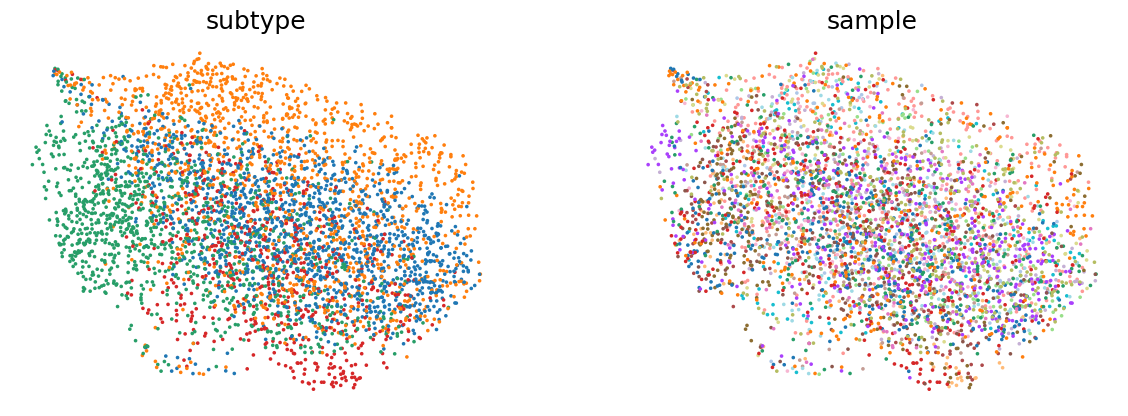

In [93]:
## Generate plots
for rep in ["X_emb"]:
    sc.pp.neighbors(adata_integrated, use_rep=rep)
    sc.tl.umap(adata_integrated)
    fig = sc.pl.umap(adata_integrated, 
            color=["subtype", "sample"], 
            frameon=False, 
            palette=sc.pl.palettes.default_20,
            legend_loc=None,
            return_fig=True)

In [99]:
# results may vary slightly given differnet seeds
bio_conservation = BioConservation(nmi_ari_cluster_labels_kmeans=False, nmi_ari_cluster_labels_leiden=True)
batch_correction = BatchCorrection(pcr_comparison=False)

bm = Benchmarker(
    adata_integrated,
    batch_key="sample",
    label_key="subtype",
    embedding_obsm_keys=["X_emb", "X", "X_pca"],
    n_jobs=6,
    bio_conservation_metrics = bio_conservation,
    batch_correction_metrics=batch_correction,
)
bm.benchmark()
print(bm.get_results())

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/3 [00:00<?, ?it/s]/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_nmi_ari.py:27: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  clustering = g.community_leiden(objective_function="modularity", weights="weight", resolution_parameter=resolution)
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_nmi_ari.py:27: DeprecationWarning: resolution_parameter keyword argument is deprecated, use resolution=... instead
  clustering = g.community_leiden(ob

              Isolated labels        Leiden NMI        Leiden ARI  \
Embedding                                                           
X_emb                0.626744          0.918081               1.0   
X                         0.0               0.0               0.0   
X_pca                     1.0               1.0          0.816548   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI  Silhouette batch  \
Embedding                                                           
X_emb                0.436144          0.610253               1.0   
X                         0.0               0.0          0.740925   
X_pca                     1.0               1.0               0.0   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
X_emb                     1.0 

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/benchmark/_core.py:268: FutureWarning: Setting an item of incom

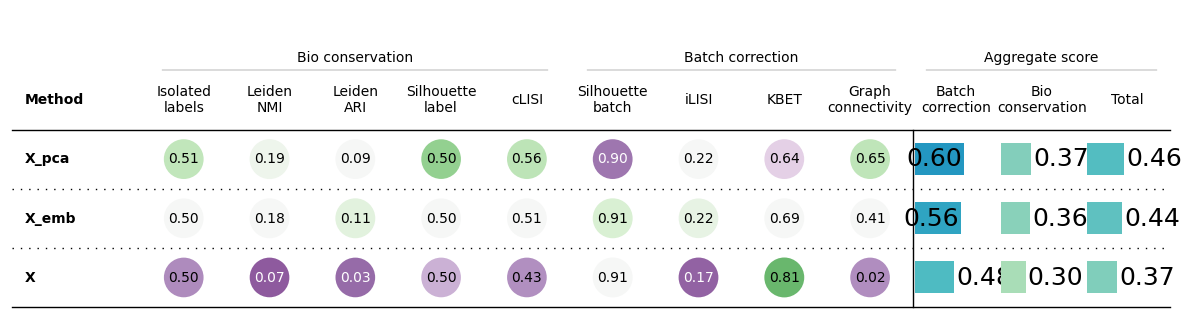

In [102]:
bm.plot_results_table(min_max_scale=False)